In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

In [84]:
df = pd.read_csv(r'data\cleaned\tablets_cleaned.csv')

In [85]:
df.isna().sum()

category                      0
name_card                   311
price                         0
price_old                     0
price_installment             0
rating_card                   0
reviews_card                  0
name_seller                   0
rating_seller                 0
url                           0
article                       3
screen_diagonal               0
ram                           0
os                            0
internal_storage              0
screen_size                   0
cpu                           0
main_camera                   0
matrix                        0
type_of_tablet                0
announcement_year             0
hz_screen                     0
ppi                           0
processor_brand               0
processor_cores               0
ghz_processor                 0
brand_graphic_proccessor      0
video_processor               0
front_camera                  0
keyboard                      0
case_material                 0
waterpro

In [86]:
df.dropna(inplace=True)

In [87]:
pd.set_option('display.max_columns', None)

In [88]:
df.head()

,category,name_card,price,price_old,price_installment,rating_card,reviews_card,name_seller,rating_seller,url,article,screen_diagonal,ram,os,internal_storage,screen_size,cpu,main_camera,matrix,type_of_tablet,announcement_year,hz_screen,ppi,processor_brand,processor_cores,ghz_processor,brand_graphic_proccessor,video_processor,front_camera,keyboard,case_material,waterproof,battery_capacity,accessories_included,dimensions,weight_g,country_of_origin,res_w,res_h,pixel_count,discount_abs,discount_pct,cpu_power_proxy,ram_per_core,storage_per_price,ram_per_price,battery_per_gram,total_camera_mp,high_refresh_rate,screen_area_proxy,keyboard_flag,stylus_flag,waterproof_flag
0,tablets,Hotwav Планшет TAB R9 Pro Планшет 11-дюймовый ...,84416.0,232764.0,7035.0,4.7,96.0,ИП Кулпеишова,4.4,https://www.ozon.kz/product/hotwav-planshet-ta...,2.135465e+09,11.0,6.0,Android,256.0,2504x1080,Tiger T606,64.0,IPS HD+,Планшет,2024.0,120.0,350.0,Unisoc,8.0,1.6,ARM,Mali-G57 MP1,16.0,Опционально,"Металл, Полимер, Силикон, Стекло, Пластик",Да,20080.0,Стилус,300*200*20,1200.0,Китай,2504.0,1080.0,2704320.0,148348.0,63.733223,12.8,0.75,0.003033,0.000071,16.733333,80.0,1,121.00,1,1,1
1,tablets,KENSHI Детский планшет KENSHI Kids E18 LTE 3/6...,79206.0,201339.0,6601.0,4.9,33.0,RS-Eectronics,4.9,https://www.ozon.kz/product/kenshi-detskiy-pla...,3.452295e+09,10.1,3.0,Android,64.0,1280x800,Tiger T310,13.0,IPS,Детский планшет,2023.0,60.0,149.0,Unisoc,4.0,2.0,PowerVR,GT7200,0.3,no_data,Пластик,no_data,5000.0,no_data,257.5x206x9.5,528.0,Китай,1280.0,800.0,1024000.0,122133.0,60.660379,8.0,0.75,0.000808,0.000038,9.469697,13.3,0,102.01,0,0,0
2,tablets,"HUAWEI Планшет, 11"" 8 ГБ/128 ГБ, серый",60747.5,302265.0,9342.0,5.0,1.0,М.Видео,4.8,https://www.ozon.kz/product/huawei-planshet-11...,3.533774e+09,11.0,8.0,Другая,128.0,1920x1200,Kirin 710A,8.0,IPS,Планшет,2025.0,120.0,264.0,HiSilicon,8.0,2.0,no_data,no_data,5.0,no_data,Металл,no_data,7700.0,Стилус,163.8x252.3x6.9,475.0,Китай,1920.0,1200.0,2304000.0,241517.5,79.902569,16.0,1.00,0.002107,0.000132,16.210526,13.0,1,121.00,0,1,0
3,tablets,"Планшет Pad Galxay S25 Ultra, 10.1"" 16 ГБ/1024...",59896.0,322078.0,4992.0,5.0,70.0,YZ Store,4.9,https://www.ozon.kz/product/planshet-pad-galxa...,3.351633e+09,10.1,16.0,Android,1024.0,2560x1600,Snapdragon 8 Gen3 Leading Version,32.0,IPS,Планшет,2025.0,140.0,264.0,Qualcomm,8.0,3.4,Qualcomm,Adreno 750,16.0,Опционально,"Металл, Пластик, Стекло",Да,10000.0,Клавиатура,214*160*8.7,300.0,Китай,2560.0,1600.0,4096000.0,262182.0,81.403263,27.2,2.00,0.017096,0.000267,33.333333,48.0,1,102.01,1,0,1
4,tablets,Honor Планшет Honor Pad GT2 Pro игровой Snapdr...,244474.0,942238.0,20373.0,4.9,33.0,DigiMart Store,4.9,https://www.ozon.kz/product/honor-planshet-hon...,3.312049e+09,12.5,8.0,Android,128.0,3048x2032,Snapdragon 8 Gen3,13.0,LCD,Планшет,2025.0,165.0,294.0,Qualcomm,8.0,3.3,Adreno,no_data,8.0,no_data,Металл,Да,10100.0,no_data,277.8 × 190.93 × 5.95 mm,580.0,Китай,3048.0,2032.0,6193536.0,697764.0,74.053901,26.4,1.00,0.000524,0.000033,17.413793,21.0,1,156.25,0,0,1


In [89]:
X = df.drop(columns=['price'])
y = df['price']

In [90]:
numerical = X.select_dtypes(include=np.number).columns

test = df[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

c:\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              feature        VIF
16       front_camera        inf
10        main_camera        inf
29    total_camera_mp        inf
24    cpu_power_proxy  60.689478
1           price_old  49.493997
22       discount_abs  47.115237
15      ghz_processor  32.604376
21        pixel_count  25.512368
7     screen_diagonal  22.322132
31  screen_area_proxy  19.892886
14    processor_cores  17.470655
8                 ram  16.609689
27      ram_per_price  15.209434
20              res_h  12.286603
19              res_w   9.819965
9    internal_storage   3.709269
12          hz_screen   3.288613
26  storage_per_price   3.182907
30  high_refresh_rate   3.041582
17   battery_capacity   2.671842
25       ram_per_core   2.402137
28   battery_per_gram   2.348675
18           weight_g   2.155624
23       discount_pct   1.741020
13                ppi   1.537993
34    waterproof_flag   1.534219
11  announcement_year   1.502944
6             article   1.468123
2   price_installment   1.453109
5       ra

In [91]:
X = X.drop(columns=['total_camera_mp', 'cpu_power_proxy', 'price_old', 'pixel_count', 'screen_area_proxy', 'ram_per_price', 'storage_per_price'])

In [92]:
numerical = X.select_dtypes(include=np.number).columns

test = df[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

c:\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


              feature       VIF
19              res_h  4.006466
18              res_w  3.648600
11          hz_screen  3.212727
24  high_refresh_rate  3.011159
9         main_camera  2.717428
7                 ram  2.647351
15       front_camera  2.572538
6     screen_diagonal  2.420582
16   battery_capacity  2.397861
22       ram_per_core  2.390576
23   battery_per_gram  2.141449
8    internal_storage  1.979207
13    processor_cores  1.950502
17           weight_g  1.566588
14      ghz_processor  1.533481
27    waterproof_flag  1.498362
10  announcement_year  1.497601
5             article  1.455314
12                ppi  1.397884
1   price_installment  1.364488
4       rating_seller  1.347848
26        stylus_flag  1.282545
20       discount_abs  1.279978
25      keyboard_flag  1.209910
21       discount_pct  1.208305
2         rating_card  1.149647
3        reviews_card  1.067794


In [93]:
X.head()

,category,name_card,price_installment,rating_card,reviews_card,name_seller,rating_seller,url,article,screen_diagonal,ram,os,internal_storage,screen_size,cpu,main_camera,matrix,type_of_tablet,announcement_year,hz_screen,ppi,processor_brand,processor_cores,ghz_processor,brand_graphic_proccessor,video_processor,front_camera,keyboard,case_material,waterproof,battery_capacity,accessories_included,dimensions,weight_g,country_of_origin,res_w,res_h,discount_abs,discount_pct,ram_per_core,battery_per_gram,high_refresh_rate,keyboard_flag,stylus_flag,waterproof_flag
0,tablets,Hotwav Планшет TAB R9 Pro Планшет 11-дюймовый ...,7035.0,4.7,96.0,ИП Кулпеишова,4.4,https://www.ozon.kz/product/hotwav-planshet-ta...,2.135465e+09,11.0,6.0,Android,256.0,2504x1080,Tiger T606,64.0,IPS HD+,Планшет,2024.0,120.0,350.0,Unisoc,8.0,1.6,ARM,Mali-G57 MP1,16.0,Опционально,"Металл, Полимер, Силикон, Стекло, Пластик",Да,20080.0,Стилус,300*200*20,1200.0,Китай,2504.0,1080.0,148348.0,63.733223,0.75,16.733333,1,1,1,1
1,tablets,KENSHI Детский планшет KENSHI Kids E18 LTE 3/6...,6601.0,4.9,33.0,RS-Eectronics,4.9,https://www.ozon.kz/product/kenshi-detskiy-pla...,3.452295e+09,10.1,3.0,Android,64.0,1280x800,Tiger T310,13.0,IPS,Детский планшет,2023.0,60.0,149.0,Unisoc,4.0,2.0,PowerVR,GT7200,0.3,no_data,Пластик,no_data,5000.0,no_data,257.5x206x9.5,528.0,Китай,1280.0,800.0,122133.0,60.660379,0.75,9.469697,0,0,0,0
2,tablets,"HUAWEI Планшет, 11"" 8 ГБ/128 ГБ, серый",9342.0,5.0,1.0,М.Видео,4.8,https://www.ozon.kz/product/huawei-planshet-11...,3.533774e+09,11.0,8.0,Другая,128.0,1920x1200,Kirin 710A,8.0,IPS,Планшет,2025.0,120.0,264.0,HiSilicon,8.0,2.0,no_data,no_data,5.0,no_data,Металл,no_data,7700.0,Стилус,163.8x252.3x6.9,475.0,Китай,1920.0,1200.0,241517.5,79.902569,1.00,16.210526,1,0,1,0
3,tablets,"Планшет Pad Galxay S25 Ultra, 10.1"" 16 ГБ/1024...",4992.0,5.0,70.0,YZ Store,4.9,https://www.ozon.kz/product/planshet-pad-galxa...,3.351633e+09,10.1,16.0,Android,1024.0,2560x1600,Snapdragon 8 Gen3 Leading Version,32.0,IPS,Планшет,2025.0,140.0,264.0,Qualcomm,8.0,3.4,Qualcomm,Adreno 750,16.0,Опционально,"Металл, Пластик, Стекло",Да,10000.0,Клавиатура,214*160*8.7,300.0,Китай,2560.0,1600.0,262182.0,81.403263,2.00,33.333333,1,1,0,1
4,tablets,Honor Планшет Honor Pad GT2 Pro игровой Snapdr...,20373.0,4.9,33.0,DigiMart Store,4.9,https://www.ozon.kz/product/honor-planshet-hon...,3.312049e+09,12.5,8.0,Android,128.0,3048x2032,Snapdragon 8 Gen3,13.0,LCD,Планшет,2025.0,165.0,294.0,Qualcomm,8.0,3.3,Adreno,no_data,8.0,no_data,Металл,Да,10100.0,no_data,277.8 × 190.93 × 5.95 mm,580.0,Китай,3048.0,2032.0,697764.0,74.053901,1.00,17.413793,1,0,0,1


In [94]:
df['country_of_origin'].value_counts()

country_of_origin
Китай                     4123
no_data                    760
Вьетнам                    204
США                         44
Россия                      27
Китай (Гонконг)             27
Кыргызстан                  12
Китай (Тайвань)             12
Китай, Китай (Гонконг)       8
Корея                        6
Кыргызская Республика        4
Беларусь                     4
Южная Корея                  2
Не указана                   2
Китай, Индия, Вьетнам        1
КНДР                         1
Вьетнам, Китай               1
Китай, Вьетнам               1
Китай (Гонконг), Китай       1
Индия, Китай                 1
Казахстан                    1
Name: count, dtype: int64

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

counts = X_train['name_seller'].value_counts()
seller_size_map = pd.qcut(counts, q=3, labels=['Small', 'Medium', 'Large']).to_dict()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['seller_category'] = X_train['name_seller'].map(seller_size_map)
X_test['seller_category'] = X_test['name_seller'].map(seller_size_map)

In [96]:
norm = df[numerical].drop(columns=['price_installment', 'battery_capacity','discount_abs', 'discount_pct']).columns.to_list()

In [97]:
huge_feat_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('huge', huge_feat_pipe, ['price_installment', 'battery_capacity']),
    ('norm', StandardScaler(), norm),
    ('OHE', OneHotEncoder(handle_unknown='ignore'), ['os', 'type_of_tablet', 'keyboard', 'brand_graphic_proccessor', 'seller_category', 'country_of_origin', 'accessories_included', 'processor_brand'])
])

In [98]:
target_pipe = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), ['price'])
])

In [99]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [100]:
param_dist = {
    'model__alpha': loguniform(1e-3, 1e3),
    'model__fit_intercept': [True, False],
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

In [101]:
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [102]:
ridge_search.fit(X_train, target_pipe.fit_transform(y_train.to_frame()).ravel())

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': <scipy.stats....0018034B743E0>, 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [103]:
print("Best params:", ridge_search.best_params_)
print("Best RMSE:", -ridge_search.best_score_)

Best params: {'model__alpha': np.float64(4.387382373522994), 'model__fit_intercept': True, 'model__solver': 'auto'}
Best RMSE: 0.5438765480758506


In [104]:
best_ridge = ridge_search.best_estimator_

In [105]:
y_pred = best_ridge.predict(X_test)
y_pred_exp = np.expm1(y_pred)

In [106]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_exp)))
print("Test R^2:", r2_score(y_test, y_pred_exp))

Test RMSE: 147172.66601671034
Test R^2: 0.37743722574948246


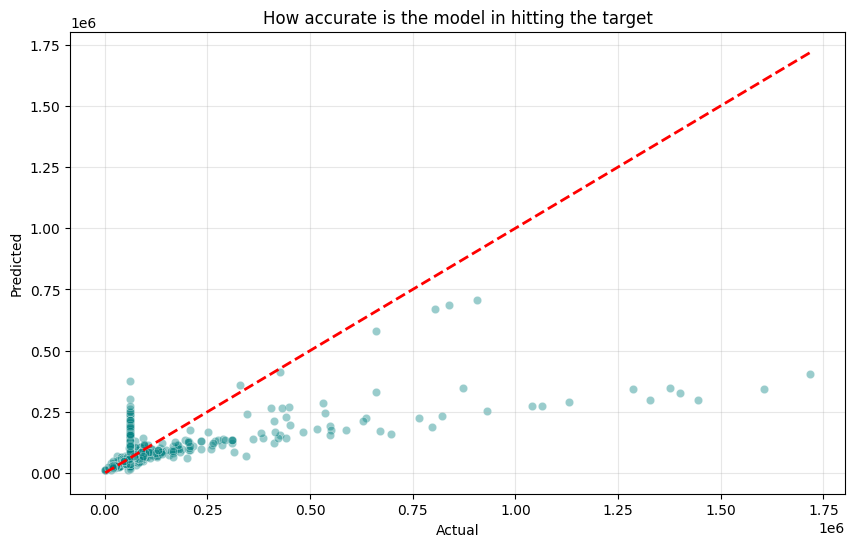

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_exp, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('How accurate is the model in hitting the target')
plt.grid(True, alpha=0.3)
plt.show()

In [108]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_exp,
    'error_pct': np.abs(y_test - y_pred_exp) / y_test * 100
})
print(results_df.nlargest(10, 'error_pct'))

       actual      predicted   error_pct
4044   1647.0   12116.116877  635.647655
3079   1602.0   11771.388832  634.793310
4825  60747.5  376021.568149  518.991017
3046   2065.0   12509.120155  505.768531
4854  60747.5  304434.124561  401.146754
4481  60747.5  274951.944862  352.614420
4454  60747.5  262712.191248  332.465848
4840   3409.0   14688.557217  330.875835
2616  60747.5  254677.505614  319.239484
835   60747.5  250528.302144  312.409238


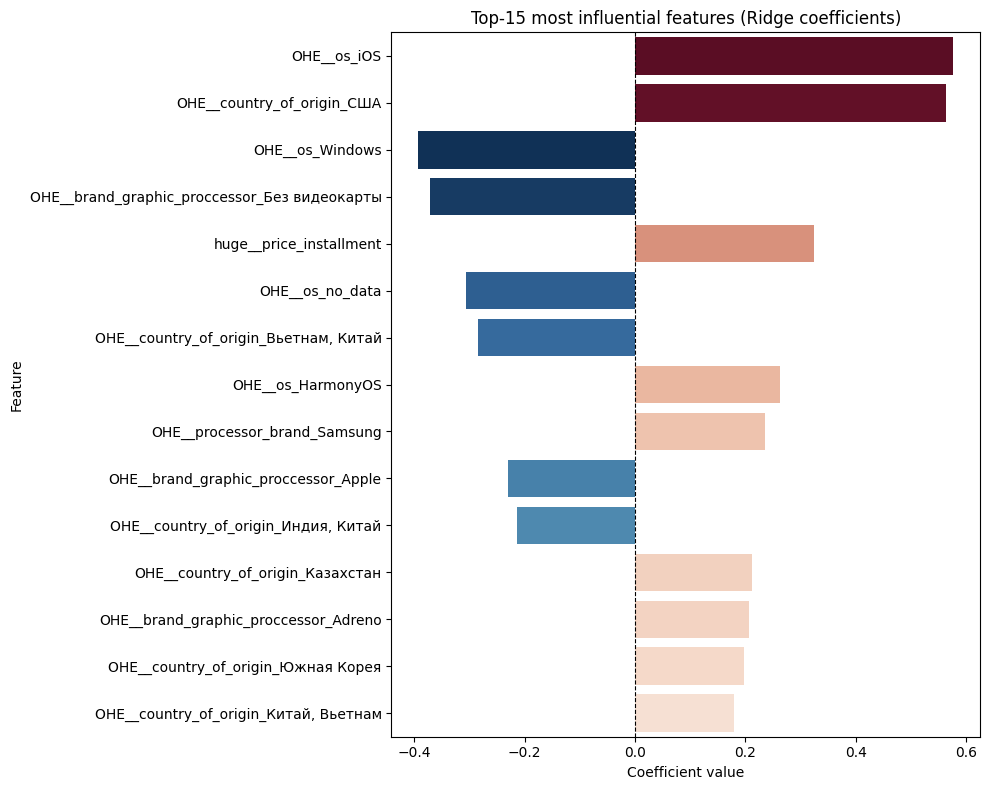

In [109]:
feature_names = best_ridge.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_ridge.named_steps['model'].coef_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=feat_imp_df.head(15),
    palette='RdBu_r',
    hue='coefficient',
    legend=False
)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top-15 most influential features (Ridge coefficients)')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# CatBoost

In [110]:
cat_cols = [
    'os', 'type_of_tablet', 'keyboard', 'brand_graphic_proccessor',
    'seller_category', 'country_of_origin', 'accessories_included', 'processor_brand'
]

num_cols = norm + ['battery_capacity']

In [111]:
cb_features = num_cols + [c for c in cat_cols if c in X_train.columns]

X_train_cb = X_train[cb_features].copy()
X_test_cb  = X_test[cb_features].copy()

for c in cat_cols:
    if c in X_train_cb.columns:
        X_train_cb[c] = X_train_cb[c].astype(str).fillna('no_data')
        X_test_cb[c]  = X_test_cb[c].astype(str).fillna('no_data')

cat_indices = [X_train_cb.columns.tolist().index(c) for c in cat_cols if c in X_train_cb.columns]

In [112]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

In [113]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

cb_model.fit(
    X_train_cb, y_train_log,
    cat_features=cat_indices,
    eval_set=(X_test_cb, y_test_log)
)

0:	learn: 0.7715022	test: 0.7602884	best: 0.7602884 (0)	total: 66.4ms	remaining: 1m 6s
100:	learn: 0.4524841	test: 0.4434272	best: 0.4434272 (100)	total: 6.71s	remaining: 59.7s
200:	learn: 0.4107069	test: 0.4243046	best: 0.4243046 (200)	total: 13.3s	remaining: 52.7s
300:	learn: 0.3788557	test: 0.4145292	best: 0.4143996 (299)	total: 20.2s	remaining: 47s
400:	learn: 0.3604570	test: 0.4086975	best: 0.4086975 (400)	total: 26.5s	remaining: 39.6s
500:	learn: 0.3447791	test: 0.4046663	best: 0.4045394 (497)	total: 32.7s	remaining: 32.6s
600:	learn: 0.3324192	test: 0.4033817	best: 0.4030502 (576)	total: 39.2s	remaining: 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4030501561
bestIteration = 576

Shrink model to first 577 iterations.


In [114]:
y_pred_log = cb_model.predict(X_test_cb)
y_pred_cb  = np.expm1(y_pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2 = r2_score(y_test, y_pred_cb)

print(f"CatBoost RMSE (log scale): {rmse_log:.4f}")
print(f"CatBoost R²  (orig scale): {r2:.4f}")

CatBoost RMSE (log scale): 0.4031
CatBoost R²  (orig scale): 0.7397


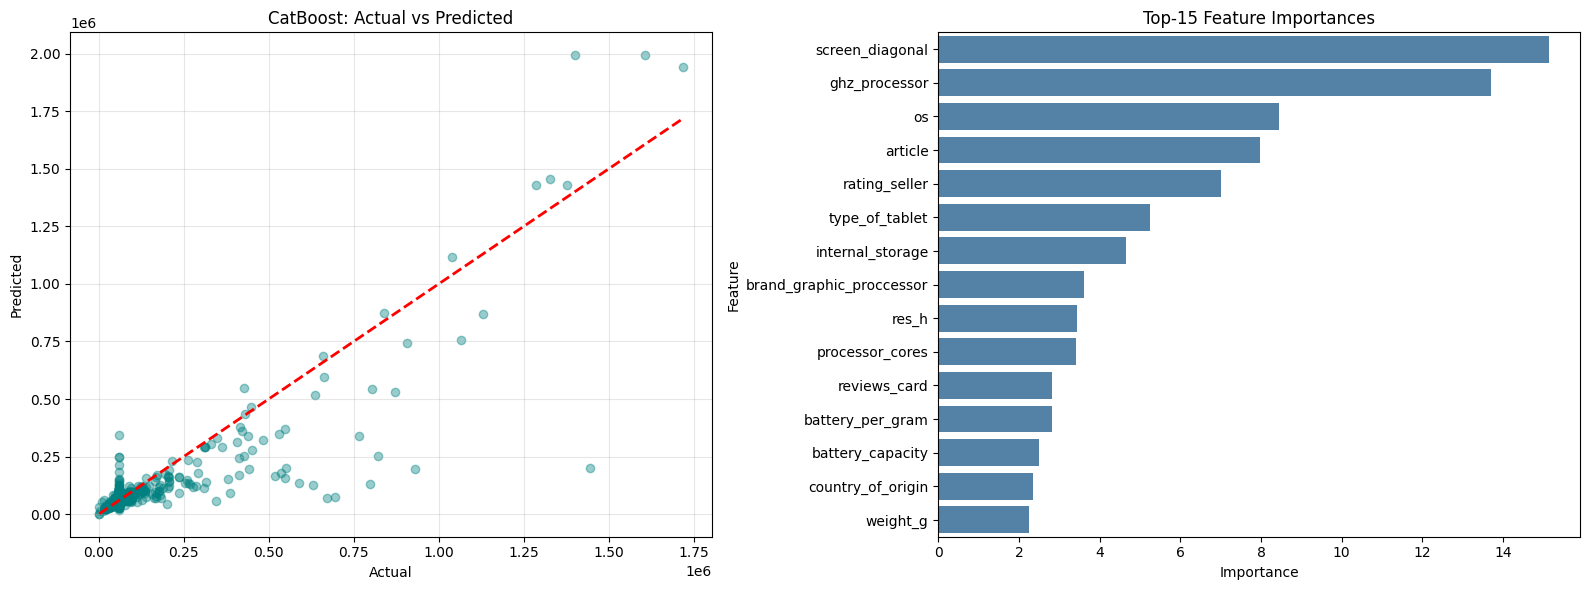

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_cb, alpha=0.4, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('CatBoost: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

feat_imp = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)

sns.barplot(data=feat_imp.head(15), x='importance', y='feature', ax=axes[1], color='steelblue')
axes[1].set_title('Top-15 Feature Importances')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()